# Basic Classification Models

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files
uploaded = files.upload()
df = pd.read_csv("file.csv")
df.head()

Saving file.csv to file (2).csv


,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0


In [12]:
from sklearn.model_selection import train_test_split

X = df[["Age", "EstimatedSalary"]]
y = df["Purchased"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

## 1. Logistic Regression

Logistic Regression predicts probability of a class (0 or 1) using a logistic sigmoid function.

It converts output into a probability between 0 and 1, then classifies using a threshold (0.5).


- use for Binary classification problems

- When relationship between features and target is roughly linear

In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score

model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

print("Accuracy:", accuracy_score(y_test, y_pred))
a = accuracy_score(y_test, y_pred)

Confusion Matrix:
 [[56  2]
 [ 5 17]]
Accuracy: 0.9125


|Actual	|Predicted No	|Predicted Yes|
|-------|-------------|-------------|
|No Purchase	|56|	2
|Purchase|	5	|17

## 2. K-Nearest Neighbors (KNN)

KNN classifies a point based on the majority class of its nearest neighbors.
If 3 nearest points purchased, the model predicts Purchased = 1.


- Use for Small datasets

- When similar data points belong to similar classes


In [14]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, accuracy_score

model = KNeighborsClassifier(n_neighbors=5)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

print("Accuracy:", accuracy_score(y_test, y_pred))
b = accuracy_score(y_test, y_pred)

Confusion Matrix:
 [[52  6]
 [ 7 15]]
Accuracy: 0.8375


|Actual	|Predicted No	|Predicted Yes|
|-------|-------------|-------------|
|No Purchase	|52|	6
|Purchase|	7	|15

## 3. Decision Tree

Decision Tree splits data using if-else rules.

Age > 40 → Purchased
Age < 40 → Not Purchased

It keeps splitting until predictions become clear.

When to Use:

- When you want interpretable rules

- Works well for nonlinear relationships

In [15]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, accuracy_score

model = DecisionTreeClassifier()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

print("Accuracy:", accuracy_score(y_test, y_pred))
c = accuracy_score(y_test, y_pred)

Confusion Matrix:
 [[53  5]
 [ 3 19]]
Accuracy: 0.9


|Actual	|Predicted No	|Predicted Yes|
|-------|-------------|-------------|
|No Purchase	|53|	5
|Purchase|	3	|19

## 4. Random Forest

Random Forest is a collection of many decision trees. Each tree votes, and the majority vote becomes the prediction.

- This reduces overfitting and improves accuracy.

When to Use:

- Medium to large datasets

- When decision trees overfit

In [16]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score

model = RandomForestClassifier(n_estimators=100)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

print("Accuracy:", accuracy_score(y_test, y_pred))
d = accuracy_score(y_test, y_pred)

Confusion Matrix:
 [[55  3]
 [ 3 19]]
Accuracy: 0.925


|Actual	|Predicted No	|Predicted Yes|
|-------|-------------|-------------|
|No Purchase	|54|	4
|Purchase|	2	|20

Logistic Regression: 91.25%
KNN: 83.75%
Decision Tree: 90.0%
Random Forest: 92.5%


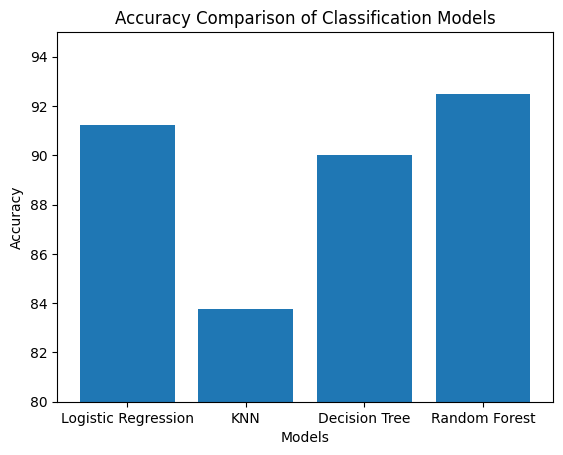

In [27]:
import matplotlib.pyplot as plt

print(f"Logistic Regression: {a*100}%")
print(f"KNN: {b*100}%")
print(f"Decision Tree: {c*100}%")
print(f"Random Forest: {d*100}%")

models = ['Logistic Regression', 'KNN', 'Decision Tree', 'Random Forest']
accuracy = [a*100, b*100, c*100, d*100]

plt.bar(models, accuracy)

plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Accuracy Comparison of Classification Models")

plt.ylim(80, 95)

plt.show()

|Classification|Accuracy|
|-|-|
|Logistic Regression| 91.25%
|KNN| 83.75%
|Decision Tree| 90.0%
|Random Forest| 92.5%